In [ ]:
# Importing libraries
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from cuml.svm import SVC as cumlSVC #works on GPU (faster)

np.random.seed(42) #set this seed for reproductability

# Downloading and loading the SVHN Dataset
!wget -nc http://ufldl.stanford.edu/housenumbers/train_32x32.mat

def load_svhn(path):
    data = loadmat(path)
    X = np.transpose(data['X'], (3,0,1,2))
    y = data['y'].reshape(-1)
    y[y == 10] = 0
    return X, y

X, y = load_svhn('train_32x32.mat') #in this homework I wont use the test_32x32 just for easier management of the train--->train+valid+test
print('Dataset shape:', X.shape, y.shape)

#splitting into train-valid-train 60/20/20%
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

# Preprocessing our Data
X_train_f = X_train.reshape(X_train.shape[0], -1).astype(np.float32) #flattening the input
X_val_f = X_val.reshape(X_val.shape[0], -1).astype(np.float32)
X_test_f = X_test.reshape(X_test.shape[0], -1).astype(np.float32)

scaler = StandardScaler() #standardization
X_train_s = scaler.fit_transform(X_train_f)
X_val_s = scaler.transform(X_val_f)
X_test_s = scaler.transform(X_test_f)

# PCA keeping 90% of the variance
from sklearn.decomposition import PCA as skPCA
pca_sk = skPCA(n_components=0.90, svd_solver='full')
X_train_p = pca_sk.fit_transform(X_train_s)
X_val_p = pca_sk.transform(X_val_s)
X_test_p = pca_sk.transform(X_test_s)

print('Number of PCA components:', X_train_p.shape[1])  #just to know in which dimension  R^n our transformed data belong to

X_train_p = X_train_p.astype(np.float32)
X_val_p = X_val_p.astype(np.float32)
X_test_p = X_test_p.astype(np.float32)
#converting to that datatype just works better for cuML

--2025-12-21 17:20:00--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  17.2MB/s    in 17s     

2025-12-21 17:20:18 (9.99 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

Dataset shape: (73257, 32, 32, 3) (73257,)
Train: (43954, 32, 32, 3) Val: (14651, 32, 32, 3) Test: (14652, 32, 32, 3)
Number of PCA components: 26


Testing Linear SVM with C=1e-05
Val Acc=0.2160, Training time=0.73s
Testing Linear SVM with C=0.01
Val Acc=0.2168, Training time=0.25s
Testing Linear SVM with C=0.1
Val Acc=0.2172, Training time=0.22s
Testing Linear SVM with C=1
Val Acc=0.2172, Training time=0.17s
Testing Linear SVM with C=10
Val Acc=0.2173, Training time=0.15s
Testing Linear SVM with C=100
Val Acc=0.2174, Training time=0.14s
Testing Linear SVM with C=10000
Val Acc=0.2170, Training time=0.15s
Testing Linear SVM with C=100000000
Val Acc=0.2171, Training time=0.15s
Best Linear SVM C: 100 Val Acc: 0.21739130434782608
Test accuracy of the Best Linear SVM: 0.21805896805896807


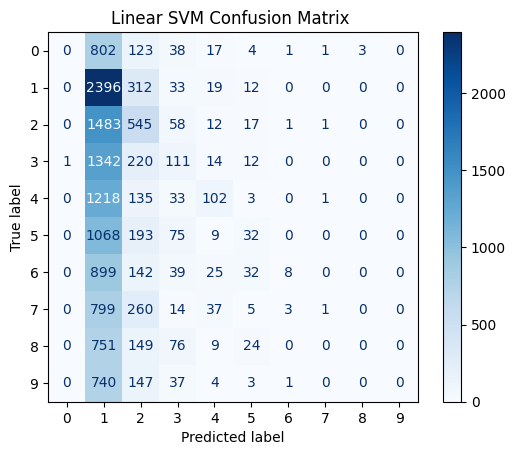

In [ ]:
#Linear SVM
from cuml.svm import LinearSVC as cumlLinearSVC  #C stands for classifier here but it still is SVM

C_values = [0.00001,0.01, 0.1, 1, 10, 100,10000,100000000]
best_val_acc_linear = 0    #keeping track of which value performs better
best_C_linear = None

for C in C_values:
    print(f'Testing Linear SVM with C={C}')
    model = cumlLinearSVC(C=C)
    start_time = time.time()
    model.fit(X_train_p, y_train) #I put as input the PCA'd data
    train_time = time.time() - start_time
    val_acc = model.score(X_val_p, y_val) #validate on the same data
    print(f'Val Acc={val_acc:.4f}, Training time={train_time:.2f}s')
    if val_acc > best_val_acc_linear:  #storing the best C and its accuraccy
        best_val_acc_linear = val_acc
        best_C_linear = C

print('Best Linear SVM C:', best_C_linear, 'Val Acc:', best_val_acc_linear)

# Retrain on train+val
X_train_val_p = np.vstack([X_train_p, X_val_p])  #samples->vertical stack
y_train_val = np.hstack([y_train, y_val]) #labels->horizontal stack

final_linear_svc = cumlLinearSVC(C=best_C_linear)
final_linear_svc.fit(X_train_val_p, y_train_val)

# Test on the best out of all the models, retrained on train+valid this time
test_acc_linear = final_linear_svc.score(X_test_p, y_test)
print('Test accuracy of the Best Linear SVM:', test_acc_linear)

# Conf matrix
y_pred_linear = final_linear_svc.predict(X_test_p)
cm_linear = confusion_matrix(y_test, y_pred_linear)
ConfusionMatrixDisplay(cm_linear).plot(cmap='Blues')
plt.title('Linear SVM Confusion Matrix ')
plt.show()



#after run comments: no matter how much I punish the model (different C) the accuraccy stays around 21% which leads to the possible conclusion that the bottleneck is the linearity that doesnt help the non-linearly
#seperable data in this case and not how much I allow the model to make mistakes or not (C)

Testing RBF SVM: C=0.1, gamma=0.001
Val Acc=0.4751, Training time=5.58s
Testing RBF SVM: C=0.1, gamma=0.01
Val Acc=0.1892, Training time=4.65s
Testing RBF SVM: C=0.1, gamma=0.1
Val Acc=0.1892, Training time=5.72s
Testing RBF SVM: C=0.1, gamma=1
Val Acc=0.1892, Training time=5.76s
Testing RBF SVM: C=1, gamma=0.001
Val Acc=0.6624, Training time=3.66s
Testing RBF SVM: C=1, gamma=0.01
Val Acc=0.3314, Training time=6.65s
Testing RBF SVM: C=1, gamma=0.1
Val Acc=0.1903, Training time=7.65s
Testing RBF SVM: C=1, gamma=1
Val Acc=0.1902, Training time=7.70s
Testing RBF SVM: C=10, gamma=0.001
Val Acc=0.6885, Training time=10.69s
Testing RBF SVM: C=10, gamma=0.01
Val Acc=0.3651, Training time=7.29s
Testing RBF SVM: C=10, gamma=0.1
Val Acc=0.1903, Training time=8.94s
Testing RBF SVM: C=10, gamma=1
Val Acc=0.1902, Training time=8.99s
Testing RBF SVM: C=100, gamma=0.001
Val Acc=0.6651, Training time=21.30s
Testing RBF SVM: C=100, gamma=0.01
Val Acc=0.3651, Training time=7.32s
Testing RBF SVM: C=100, 

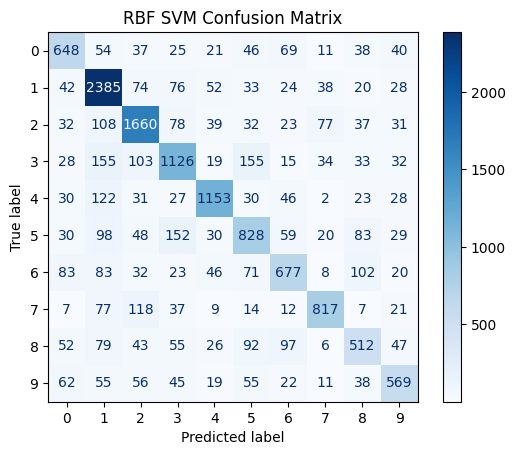

In [ ]:
#RBF SVM

C_values = [0.1, 1, 10,100]
gamma_values = [0.001, 0.01, 0.1,1] #will follow the same procedure but now the hyperparameters are C (same as before) and the gamma (big or small extent of the RBF kernel)

best_val_acc_rbf = 0
best_params_rbf = None

for C in C_values:
    for gamma in gamma_values:
        print(f'Testing RBF SVM: C={C}, gamma={gamma}')
        model = cumlSVC(C=C, kernel='rbf', gamma=gamma) #2 parameters here
        start_time = time.time()
        model.fit(X_train_p, y_train)
        train_time = time.time() - start_time
        val_acc = model.score(X_val_p, y_val)
        print(f'Val Acc={val_acc:.4f}, Training time={train_time:.2f}s')
        if val_acc > best_val_acc_rbf:
            best_val_acc_rbf = val_acc
            best_params_rbf = {'C': C, 'gamma': gamma}

print('Best RBF SVM parameters:', best_params_rbf, 'Val Acc:', best_val_acc_rbf)

# Retrain on train+val
X_train_val_p = np.vstack([X_train_p, X_val_p])
y_train_val = np.hstack([y_train, y_val])

final_rbf_svm = cumlSVC(**best_params_rbf, kernel='rbf')  #unpacking best parameters
final_rbf_svm.fit(X_train_val_p, y_train_val)

# Testing
test_acc_rbf = final_rbf_svm.score(X_test_p, y_test)
print('Test accuracy of RBF SVM:', test_acc_rbf)

# Confusion matrix
y_pred_rbf = final_rbf_svm.predict(X_test_p)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
ConfusionMatrixDisplay(cm_rbf).plot(cmap='Blues')
plt.title('RBF SVM Confusion Matrix')
plt.show()

Testing Polynomial SVM: C=0.1, degree=2
Validation accuracy: 0.4441, Train time: 5.70s
Testing Polynomial SVM: C=0.1, degree=3
Validation accuracy: 0.5556, Train time: 5.74s
Testing Polynomial SVM: C=0.1, degree=4
Validation accuracy: 0.6251, Train time: 6.66s
Testing Polynomial SVM: C=1, degree=2
Validation accuracy: 0.6325, Train time: 6.51s
Testing Polynomial SVM: C=1, degree=3
Validation accuracy: 0.6825, Train time: 12.61s
Testing Polynomial SVM: C=1, degree=4
Validation accuracy: 0.7064, Train time: 15.76s
Testing Polynomial SVM: C=10, degree=2
Validation accuracy: 0.7175, Train time: 20.59s
Testing Polynomial SVM: C=10, degree=3
Validation accuracy: 0.7215, Train time: 57.98s
Testing Polynomial SVM: C=10, degree=4
Validation accuracy: 0.7129, Train time: 53.11s
Best Polynomial SVM params: {'C': 10, 'degree': 3} Val Acc: 0.7215207153095352
Final TEST accuracy: 0.7324597324597325


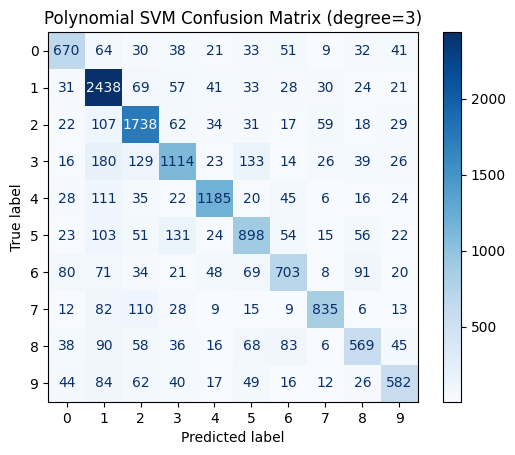

In [ ]:
#Polynomial SVM

C_values = [0.1, 1, 10]
degree_values = [2, 3, 4]
coef0 = 1.0                     #set to 1 as it is in the course notes (I will try different value later)

best_val_acc_poly = 0
best_params_poly = None


for C in C_values:
    for degree in degree_values:
        print(f"Testing Polynomial SVM: C={C}, degree={degree}")
        model = cumlSVC(kernel="poly", C=C, degree=degree, coef0=coef0, gamma="scale")
        start_time = time.time()
        model.fit(X_train_p, y_train)
        train_time = time.time() - start_time
        val_acc = model.score(X_val_p, y_val)
        print(f"Validation accuracy: {val_acc:.4f}, Train time: {train_time:.2f}s")
        if val_acc > best_val_acc_poly:
            best_val_acc_poly = val_acc
            best_params_poly = {"C": C, "degree": degree}

print("Best Polynomial SVM params:", best_params_poly, "Val Acc:", best_val_acc_poly)

# Retrain on train + val
X_train_val = np.vstack([X_train_p, X_val_p])
y_train_val = np.hstack([y_train, y_val])

final_poly_svm = cumlSVC(
    kernel="poly",
    C=best_params_poly["C"],
    degree=best_params_poly["degree"],
    coef0=coef0,
    gamma="scale" #default
)

start_time = time.time()
final_poly_svm.fit(X_train_val, y_train_val)
retrain_time = time.time() - start_time

#Testing
test_acc = final_poly_svm.score(X_test_p, y_test)
print("Final TEST accuracy:", test_acc)

# Confusion matrix
y_pred = final_poly_svm.predict(X_test_p)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Polynomial SVM Confusion Matrix (degree={best_params_poly['degree']})")
plt.show()



Polynomial SVM (degree=7, C=1.0)
Train time: 43.28s
Validation accuracy: 0.6845
Retrain time (train+val): 75.37s
Test accuracy: 0.7007917007917008


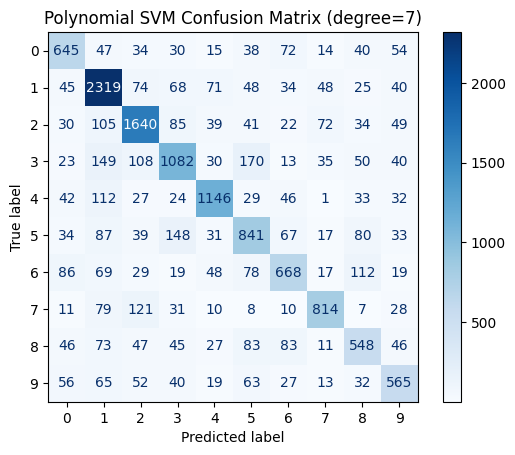

In [ ]:
#I put the degree set to 10 to 'overfit' on purpose the model

large_degree = 7  #couldnt try bigger degree bcs of the working cache memory limitation
C_value = 1.0
coef0_default = 1.0    #the usual value of 1 (x.y+1)

poly_overfit_svm = cumlSVC(
    kernel="poly",
    degree=large_degree,
    coef0=coef0_default,
    C=C_value,
    gamma="scale"
)

# Train on train set
start = time.time()
poly_overfit_svm.fit(X_train_p, y_train)
train_time = time.time() - start

val_acc = poly_overfit_svm.score(X_val_p, y_val)

print(f"Polynomial SVM (degree={large_degree}, C={C_value})")
print(f"Train time: {train_time:.2f}s")
print(f"Validation accuracy: {val_acc:.4f}")

# Retrain on train+val
X_train_val = np.vstack([X_train_p, X_val_p])
y_train_val = np.hstack([y_train, y_val])

final_poly_overfit = cumlSVC(
    kernel="poly",
    degree=large_degree,
    coef0=coef0_default,
    C=C_value,
    gamma="scale"
)

start = time.time()
final_poly_overfit.fit(X_train_val, y_train_val)
retrain_time = time.time() - start
print(f"Retrain time (train+val): {retrain_time:.2f}s")

# Testing
test_acc = final_poly_overfit.score(X_test_p, y_test)
print("Test accuracy:", test_acc)

# Confusion matrix
y_pred = final_poly_overfit.predict(X_test_p)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Polynomial SVM Confusion Matrix (degree={large_degree})")
plt.show()


Polynomial SVM (degree=3, coef0=0.0, C=10)
Train time: 118.91s
Validation accuracy: 0.3030
Retrain time (train+val): 175.25s
Final TEST accuracy: 0.31476931476931475


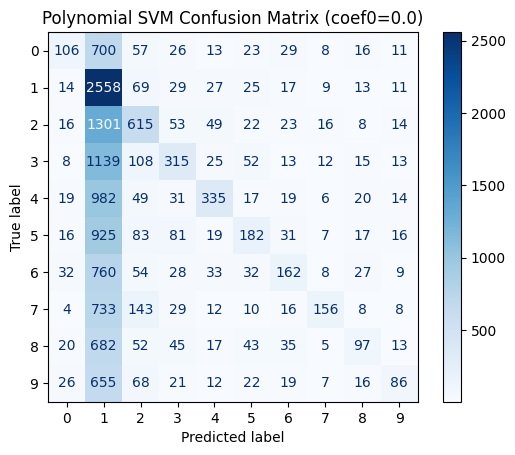

In [ ]:
#coefficent set to 0

degree_default = 3      #take the degree and c_val that gave me the better results last time but this time change the coeff 1-->0
C_value = 10
coef0_zero = 0.0

poly_coef0_zero_svm = cumlSVC(
    kernel="poly",
    degree=degree_default,
    coef0=coef0_zero,
    C=C_value,
    gamma="scale"
)

# Train on train set
start = time.time()
poly_coef0_zero_svm.fit(X_train_p, y_train)
train_time = time.time() - start

val_acc = poly_coef0_zero_svm.score(X_val_p, y_val)

print(f"Polynomial SVM (degree={degree_default}, coef0={coef0_zero}, C={C_value})")
print(f"Train time: {train_time:.2f}s")
print(f"Validation accuracy: {val_acc:.4f}")

# Retrain on train+val
X_train_val = np.vstack([X_train_p, X_val_p])
y_train_val = np.hstack([y_train, y_val])

final_poly_coef0_zero = cumlSVC(
    kernel="poly",
    degree=degree_default,
    coef0=coef0_zero,
    C=C_value,
    gamma="scale"
)

start = time.time()
final_poly_coef0_zero.fit(X_train_val, y_train_val)
retrain_time = time.time() - start
print(f"Retrain time (train+val): {retrain_time:.2f}s")

# Testing
test_acc = final_poly_coef0_zero.score(X_test_p, y_test)
print("Final TEST accuracy:", test_acc)

# Confusion matrix
y_pred = final_poly_coef0_zero.predict(X_test_p)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Polynomial SVM Confusion Matrix (coef0={coef0_zero})")
plt.show()



#after run comments: just a slight difference in the coeff from 1-->0 proved to be vital and reduced the test accuraccy 40%
# this may be due to the fact that when x or y are near 0 (x.y)^d is getting even closer to 0 and the model becomes unstable
#coeff=1 gives us the advantage that (values>1)^d>>1 while (values<1)^d<<1 where values=x.y+1 and this makes the seperation easier

In [ ]:
!pip install torch==2.9.0+cu126 torchvision==0.15.1+cu126 torchaudio==2.0.2+cu126 --extra-index-url https://download.pytorch.org/whl/cu126


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.15.1+cu126 (from versions: 0.1.6, 0.2.0, 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.21.0+cu126, 0.22.0, 0.22.0+cu126, 0.22.1, 0.22.1+cu126, 0.23.0, 0.23.0+cu126, 0.24.0, 0.24.0+cu126, 0.24.1, 0.24.1+cu126)
ERROR: No matching distribution found for torchvision==0.15.1+cu126


Reference from the Paper: UNSUPERVISED REPRESENTATION LEARNING BY PREDICTING IMAGE ROTATIONS
Spyros Gidaris, Praveer Singh, Nikos Komodakis
University Paris-Est, LIGM
Ecole des Ponts ParisTech

Our work follows the self-supervised paradigm and proposes to learn image representations by training ConvNets to recognize the geometric transformation that is applied to the image that it gets as
input. More specifically, we first define a small set of discrete geometric transformations, then each
of those geometric transformations are applied to each image on the dataset and the produced transformed images are fed to the ConvNet model that is trained to recognize the transformation of each
image. In this formulation, it is the set of geometric transformations that actually defines the classification pretext task that the ConvNet model has to learn. Therefore, in order to achieve unsupervised
semantic feature learning, it is of crucial importance to properly choose those geometric transformations (we further discuss this aspect of our methodology in section 2.2). What we propose is to
define the geometric transformations as the image rotations by 0, 90, 180, and 270 degrees. Thus,
the ConvNet model is trained on the 4-way image classification task of recognizing one of the four
image rotations (see Figure 2). We argue that in order a ConvNet model to be able recognize the
rotation transformation that was applied to an image it will require to understand the concept of
the objects depicted in the image (see Figure 1), such as their location in the image, their type, and
their pose. Throughout the paper we support that argument both qualitatively and quantitatively.
Furthermore we demonstrate on the experimental section of the paper that despite the simplicity of
our self-supervised approach, the task of predicting rotation transformations provides a powerful
surrogate supervision signal for feature learning and leads to dramatic improvements on the relevant
benchmarks.



Το CNN μαθαίνει features που βοηθούν να μαντέψει την rotation

Τρέχουμε το CNN σε εικόνες χωρίς labels και παίρνουμε το 256-D feature vector

Αυτό είναι το embedding της εικόνας.

In [ ]:
#idea from paper:   Unsupervised Representation Learning By Predicting Image Rotations (Spyros Gidaris, Paveer Singh, Nikos Komodakis)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import StandardScaler
from cuml.svm import SVC as cumlSVC
import time

class SimpleCNN(nn.Module):    #feature extractor, not classifier
    def __init__(self, feature_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), #input 32x32x3, conv 64 feature maps, maxpool 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16 -> 8x8  , 128 feature maps

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),  # 8x8 -> 4x4

            nn.Flatten(),
            nn.Linear(256 * 4 * 4, feature_dim),  #embedding
            nn.BatchNorm1d(feature_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

cnn = SimpleCNN(feature_dim=256).to(device)
rotation_head = nn.Linear(256, 4).to(device) #4 possible angles

class RotationDataset(Dataset):
    def __init__(self, images):
        self.images = torch.FloatTensor(images).permute(0, 3, 1, 2) / 255.0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        rot = torch.randint(0, 4, (1,)).item()
        angle = rot * 90
        rotated = transforms.functional.rotate(img, angle)
        return rotated, rot

dataset = RotationDataset(X_train) #full set
loader = DataLoader(dataset, batch_size=128, shuffle=True)

optimizer = optim.Adam(list(cnn.parameters()) + list(rotation_head.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training for 20 epochs")
for epoch in range(20):
    cnn.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        features = cnn(images)
        outputs = rotation_head(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total
    print(f"Epoch {epoch+1}: Loss: {total_loss/len(loader):.4f}, Rotation Acc: {acc:.1f}%")

print("\nExtracting features")
cnn.eval()

def extract_simple(images):
    tensor = torch.FloatTensor(images).permute(0, 3, 1, 2) / 255.0
    features = []
    batch_size = 128

    with torch.no_grad():
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i:i+batch_size].to(device)
            feat = cnn(batch).cpu().numpy()
            features.append(feat)

    return np.vstack(features)

X_train_feat = extract_simple(X_train)
X_val_feat = extract_simple(X_val)
X_test_feat = extract_simple(X_test)

print(f"Features shape: {X_train_feat.shape}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

svm = cumlSVC(C=1.0, kernel='rbf', gamma='scale')
svm.fit(X_train_scaled, y_train)

test_acc = svm.score(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"PCA Baseline:  {test_acc_rbf:.4f}")

if test_acc > test_acc_rbf:
    print(f"Improvement: {((test_acc-test_acc_rbf)/test_acc_rbf*100):.1f}%")
else:
    print("Worse than PCA")

Training for 20 epochs
Epoch 1: Loss: 0.6552, Rotation Acc: 68.0%
Epoch 2: Loss: 0.4987, Rotation Acc: 76.7%
Epoch 3: Loss: 0.4351, Rotation Acc: 80.4%
Epoch 4: Loss: 0.3979, Rotation Acc: 82.4%
Epoch 5: Loss: 0.3624, Rotation Acc: 84.1%
Epoch 6: Loss: 0.3389, Rotation Acc: 85.4%
Epoch 7: Loss: 0.3218, Rotation Acc: 86.2%
Epoch 8: Loss: 0.3073, Rotation Acc: 86.9%
Epoch 9: Loss: 0.2938, Rotation Acc: 87.5%
Epoch 10: Loss: 0.2814, Rotation Acc: 88.2%
Epoch 11: Loss: 0.2689, Rotation Acc: 88.5%
Epoch 12: Loss: 0.2592, Rotation Acc: 89.2%
Epoch 13: Loss: 0.2482, Rotation Acc: 89.7%
Epoch 14: Loss: 0.2404, Rotation Acc: 89.7%
Epoch 15: Loss: 0.2297, Rotation Acc: 90.4%
Epoch 16: Loss: 0.2252, Rotation Acc: 90.5%
Epoch 17: Loss: 0.2152, Rotation Acc: 91.1%
Epoch 18: Loss: 0.2059, Rotation Acc: 91.5%
Epoch 19: Loss: 0.1981, Rotation Acc: 91.9%
Epoch 20: Loss: 0.1914, Rotation Acc: 92.2%

Extracting features
Features shape: (43954, 256)

Test Accuracy: 0.8586
PCA Baseline:  0.7081
Improvement

Epoch 01/20 | Train Loss=1.5598 | Val Acc=0.0888
Epoch 02/20 | Train Loss=1.3913 | Val Acc=0.0887
Epoch 03/20 | Train Loss=1.2367 | Val Acc=0.0887
Epoch 04/20 | Train Loss=1.0981 | Val Acc=0.0893
Epoch 05/20 | Train Loss=0.9770 | Val Acc=0.0899
Epoch 06/20 | Train Loss=0.8731 | Val Acc=0.0904
Epoch 07/20 | Train Loss=0.7852 | Val Acc=0.0915
Epoch 08/20 | Train Loss=0.7117 | Val Acc=0.0921
Epoch 09/20 | Train Loss=0.6503 | Val Acc=0.0927
Epoch 10/20 | Train Loss=0.5984 | Val Acc=0.0939
Epoch 11/20 | Train Loss=0.5543 | Val Acc=0.0960
Epoch 12/20 | Train Loss=0.5176 | Val Acc=0.0995
Epoch 13/20 | Train Loss=0.4879 | Val Acc=0.1026
Epoch 14/20 | Train Loss=0.4648 | Val Acc=0.1074
Epoch 15/20 | Train Loss=0.4472 | Val Acc=0.1135
Epoch 16/20 | Train Loss=0.4340 | Val Acc=0.1234
Epoch 17/20 | Train Loss=0.4239 | Val Acc=0.1331
Epoch 18/20 | Train Loss=0.4161 | Val Acc=0.1407
Epoch 19/20 | Train Loss=0.4097 | Val Acc=0.1482
Epoch 20/20 | Train Loss=0.4044 | Val Acc=0.1536

Best Val Accuracy: 

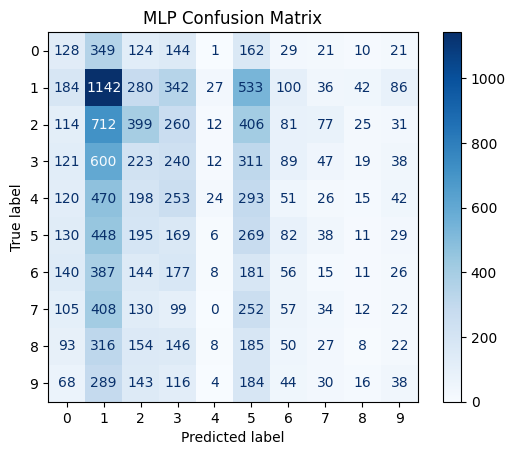

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

class HingeLoss(nn.Module):
    def forward(self, outputs, labels):
        labels_onehot = -torch.ones_like(outputs)
        labels_onehot[torch.arange(len(labels)), labels] = 1
        loss = torch.clamp(1 - outputs * labels_onehot, min=0)
        return loss.mean()

def make_mlp():
    return nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    ).to(device)

input_size = X_train_p.shape[1]
hidden_size = 128
output_size = len(np.unique(y_train))

criterion = HingeLoss()
num_epochs = 20
lr = 1e-3

X_train_t = torch.from_numpy(X_train_p).float().to(device)
y_train_t = torch.from_numpy(y_train).long().to(device)

X_val_t = torch.from_numpy(X_val_p).float().to(device)
y_val_t = torch.from_numpy(y_val).long().to(device)

X_test_t = torch.from_numpy(X_test_p).float().to(device)
y_test_t = torch.from_numpy(y_test).long().to(device)

#train on training set
mlp = make_mlp()
optimizer = optim.Adam(mlp.parameters(), lr=lr)

best_val_acc = 0
best_state = None

for epoch in range(num_epochs):
    mlp.train()
    optimizer.zero_grad()
    outputs = mlp(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    mlp.eval()
    with torch.no_grad():
        val_outputs = mlp(X_val_t)
        val_pred = val_outputs.argmax(dim=1)
        val_acc = (val_pred == y_val_t).float().mean().item()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = mlp.state_dict()

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss={loss.item():.4f} | Val Acc={val_acc:.4f}")

print("\nBest Val Accuracy:", best_val_acc)

#retrain on training and validation set
X_trainval_t = torch.cat([X_train_t, X_val_t], dim=0)
y_trainval_t = torch.cat([y_train_t, y_val_t], dim=0)

mlp_final = make_mlp()
optimizer = optim.Adam(mlp_final.parameters(), lr=lr)

for epoch in range(num_epochs):
    mlp_final.train()
    optimizer.zero_grad()
    outputs = mlp_final(X_trainval_t)
    loss = criterion(outputs, y_trainval_t)
    loss.backward()
    optimizer.step()


#testing
mlp_final.eval()
with torch.no_grad():
    test_outputs = mlp_final(X_test_t)
    y_pred_mlp = test_outputs.argmax(dim=1).cpu().numpy()
    test_acc_mlp = (y_pred_mlp == y_test).mean()

print("Test accuracy:", test_acc_mlp)

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp).plot(cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()


In [ ]:
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx   = np.where(y_pred != y_test)[0]

print("10 First correct predictions:")
for i in correct_idx[:10]:
    print(f"Index {i}: true={y_test[i]}, pred={y_pred[i]}")

print("\n10 First wrong predictions:")
for i in wrong_idx[:10]:
    print(f"Index {i}: true={y_test[i]}, pred={y_pred[i]}")


10 First correct predictions:
Index 1: true=4, pred=4
Index 14: true=1, pred=1
Index 15: true=1, pred=1
Index 17: true=1, pred=1
Index 20: true=7, pred=7
Index 23: true=0, pred=0
Index 30: true=1, pred=1
Index 33: true=1, pred=1
Index 36: true=1, pred=1
Index 46: true=1, pred=1

10 First wrong predictions:
Index 0: true=2, pred=1
Index 2: true=9, pred=1
Index 3: true=1, pred=4
Index 4: true=9, pred=1
Index 5: true=7, pred=1
Index 6: true=6, pred=1
Index 7: true=9, pred=1
Index 8: true=3, pred=1
Index 9: true=0, pred=1
Index 10: true=8, pred=1


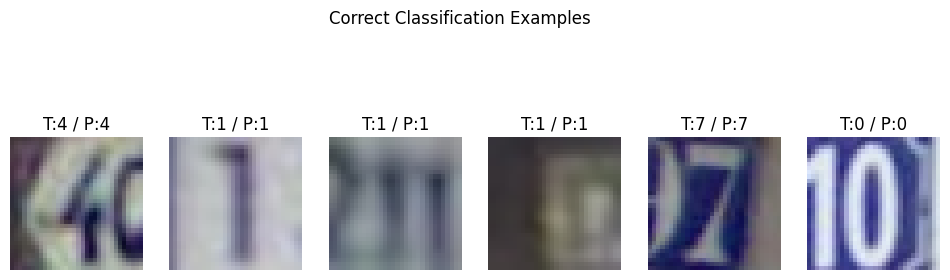

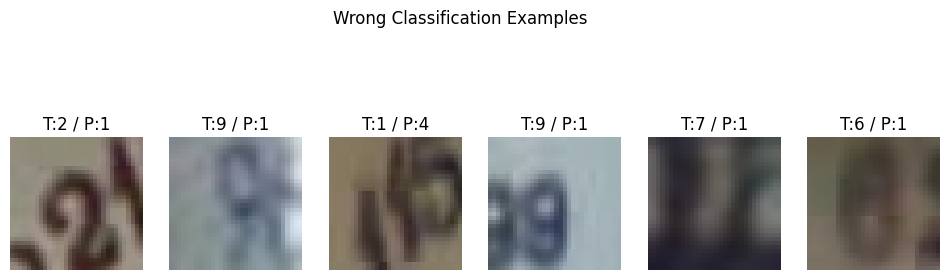

In [ ]:
def show_examples(indices, title, n=6):
    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i+1)
        plt.imshow(X_test[idx])
        plt.axis("off")
        plt.title(f"T:{y_test[idx]} / P:{y_pred[idx]}")
    plt.suptitle(title)
    plt.show()

show_examples(correct_idx, "Correct Classification Examples")

show_examples(wrong_idx, "Wrong Classification Examples")
